# Lost In Transcription — preprocessing + EDA

This is the single notebook to run before adding model code. It embeds the complete v2 builder,
materializes the local training/dev artifacts, validates them, and displays the EDA outputs.

Run top-to-bottom once. The existing processed/v1 artifact is preserved. The final section is
intentionally a model handoff point: append training/inference cells there. Keep dev_df
validation-only; use train_only_df for fitting and heldout_df for local tuning.

In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "Jember Javanese Spontaneous Speech Corpus").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "Jember Javanese Spontaneous Speech Corpus").exists():
    raise FileNotFoundError("Run this notebook from inside the LostInTranscription repository")

OUTPUT_VERSION = "v2"
REBUILD = True
print(f"Repository: {ROOT}")
print(f"Output: {ROOT / 'processed' / OUTPUT_VERSION}")

Repository: /Users/aakash/Documents/Models and Research/LostinTranscription
Output: /Users/aakash/Documents/Models and Research/LostinTranscription/processed/v2


In [2]:
"""Reproducible EDA and preprocessing for Lost In Transcription.

This module deliberately stops before ASR model training.  It builds a clean,
auditable training manifest and target-domain audit from the local Jember and
development data.

The implementation keeps three concerns separate:

* ``official_normalize_text`` mirrors the competition scorer and is used only
  for local measurement.
* ``normalize_training_text`` rewrites Jember annotation text into the target
  orthographic convention without applying the scorer's destructive rules.
* audio quality fields are measurements and flags.  They are not silently used
  to delete or reweight data beyond the explicitly documented hard gate.
"""

from __future__ import annotations

import datetime as dt
import hashlib
import json
import math
import re
import shutil
import subprocess
import unicodedata
from collections import Counter
from pathlib import Path
from typing import Any, Iterable, Mapping, Sequence

import librosa
import numpy as np
import pandas as pd
import soundfile as sf


DEFAULT_CONFIG: dict[str, Any] = {
    "version": "v2",
    "sample_rate": 16000,
    "channels": 1,
    "audio_format": "FLAC",
    "subtype": "PCM_16",
    "merge_max_dur_s": 29.0,
    "merge_max_gap_s": 1.0,
    "turn_step_db": 6.0,
    "turn_min_chunk_s": 12.0,
    "edge_pad_s": 0.15,
    "edge_margin_s": 0.20,
    "edge_trim_max_s": 1.00,
    "vad_floor_pct": 5.0,
    "vad_thresh_db": 12.0,
    "target_rms_dbfs": -23.0,
    "peak_ceiling_dbfs": -1.0,
    "drop_min_dur_s": 2.0,
    "drop_max_dur_s": 30.0,
    "drop_min_snr_db": 10.0,
    "drop_max_silence": 0.95,
    "offmic_silence_frac": 0.85,
    "low_snr_flag_db": 20.0,
    "source_clip_frac": 0.001,
    "heldout_frac": 0.10,
    "seed": 1337,
}

UNICODE_TRAINING_MAP: dict[str, str] = {
    "“": '"',
    "”": '"',
    "‘": "'",
    "’": "'",
    "…": "...",
    "–": "-",
    # The scorer treats an em dash as a sentence delimiter and then removes
    # it.  Mapping it to a hyphen would create a scored token, so use a space.
    "—": " ",
}
_UNICODE_TRAINING_RE = re.compile("|".join(map(re.escape, UNICODE_TRAINING_MAP)))

FRAME_SAMPLES = 400  # 25 ms at 16 kHz
HOP_SAMPLES = 160  # 10 ms at 16 kHz


def _is_missing(value: Any) -> bool:
    if value is None:
        return True
    try:
        missing = pd.isna(value)
    except (TypeError, ValueError):
        return False
    if isinstance(missing, (bool, np.bool_)):
        return bool(missing)
    return False


def parse_timestamp(value: Any) -> float:
    """Parse H:MM:SS, MM:SS, or seconds into a non-negative float."""

    if _is_missing(value):
        return float("nan")
    if isinstance(value, (int, float, np.integer, np.floating)):
        seconds = float(value)
    else:
        parts = [float(part) for part in str(value).strip().split(":")]
        if len(parts) == 3:
            hours, minutes, seconds_part = parts
        elif len(parts) == 2:
            hours, minutes, seconds_part = 0.0, parts[0], parts[1]
        elif len(parts) == 1:
            hours, minutes, seconds_part = 0.0, 0.0, parts[0]
        else:
            raise ValueError(f"Unsupported timestamp: {value!r}")
        seconds = hours * 3600.0 + minutes * 60.0 + seconds_part
    if not math.isfinite(seconds) or seconds < 0:
        raise ValueError(f"Timestamp must be finite and non-negative: {value!r}")
    return seconds


def _strip_combining_marks(text: str) -> str:
    decomposed = unicodedata.normalize("NFKD", text)
    return "".join(char for char in decomposed if unicodedata.category(char) != "Mn")


def normalize_training_text(value: Any) -> str:
    """Canonicalize Jember training text without changing scored structure.

    This intentionally preserves casing, hyphens, apostrophes, and
    word-attached ellipses.  It is not the scorer normalizer and must not be
    used to normalize dev references or final predictions.
    """

    if _is_missing(value):
        return ""
    text = _UNICODE_TRAINING_RE.sub(
        lambda match: UNICODE_TRAINING_MAP[match.group(0)], str(value)
    )
    text = _strip_combining_marks(text)
    return re.sub(r"\s+", " ", text).strip()


# This function is intentionally kept close to the current official
# ``score.py`` implementation.  If the runtime repository changes, update it
# from the official source and rerun the unit tests.
_BRACKETED_RE = re.compile(r"\[[^\]]+\]")
_UNINTELLIGIBLE_PAREN_RE = re.compile(r"\(\?+\)")
_WORD_PAREN_RE = re.compile(r"\(([^()]*)\)")
_PUNCTUATION_OTHER_RE = re.compile('[¿¡";:]+')
_COMMA_RE = re.compile(",+")
_SENTENCE_INITIAL_RE = re.compile(r"(^\s*|[.!?—]\s*)([^\W\d_])([^\W\d_]?)")
_SENTENCE_END_RE = re.compile("[!?]+")
_MULTISPACE_RE = re.compile("  +")


def _lowercase_sentence_initial(match: re.Match[str]) -> str:
    delimiter, first, second = match.group(1), match.group(2), match.group(3)
    if first.isupper() and not (second and second.isupper()):
        first = first.lower()
    return delimiter + first + second


def official_normalize_text(value: Any) -> str:
    """Mirror the competition's current official text normalizer."""

    if _is_missing(value):
        return ""
    text = str(value).replace("~", "")
    text = _BRACKETED_RE.sub(" ", text)
    text = _UNINTELLIGIBLE_PAREN_RE.sub(" ", text)
    text = _WORD_PAREN_RE.sub(r"\1", text)
    text = text.replace("#x27;", "'")
    text = _PUNCTUATION_OTHER_RE.sub(" ", text)
    text = _SENTENCE_INITIAL_RE.sub(_lowercase_sentence_initial, text)
    text = text.replace("—", ", ")
    text = _COMMA_RE.sub(" ", text)
    text = _SENTENCE_END_RE.sub(" ", text)
    text = text.replace("...", "!ELLIPSIS!").replace(".", " ").replace(
        "!ELLIPSIS!", "..."
    )
    while " ... " in text:
        text = text.replace(" ... ", " ")
    return _MULTISPACE_RE.sub(" ", text).strip()


def scored_tokens(value: Any) -> list[str]:
    return official_normalize_text(value).split()


def _require_columns(df: pd.DataFrame, required: Iterable[str], label: str) -> None:
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise ValueError(f"{label} is missing required columns: {missing}")


def load_metadata(root: Path) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, Path]]:
    """Load and validate the two local datasets."""

    paths = {
        "jember_tsv": root
        / "Jember Javanese Spontaneous Speech Corpus"
        / "Jember Javanese Spontaneous Speech Corpus - 1-200.tsv",
        "jember_audio": root
        / "Jember Javanese Spontaneous Speech Corpus"
        / "mp3 audio",
        "dev_tsv": root / "indonesian_dev" / "metadata.tsv",
        "dev_audio": root / "indonesian_dev" / "clips",
    }
    for name, path in paths.items():
        if not path.exists():
            raise FileNotFoundError(f"Missing {name}: {path}")

    jember = pd.read_csv(paths["jember_tsv"], sep="\t")
    dev = pd.read_csv(paths["dev_tsv"], sep="\t")
    _require_columns(jember, ["Audio file name", "start", "end", "text"], "Jember TSV")
    _require_columns(
        dev, ["audio_filename", "speaker", "transcript", "language", "convo_id"], "dev TSV"
    )

    jember = jember.copy()
    jember["session"] = pd.to_numeric(jember["Audio file name"], errors="coerce")
    if jember["session"].isna().any():
        raise ValueError("Jember contains a non-numeric session identifier")
    jember["session"] = jember["session"].astype(int)
    jember["start_s"] = jember["start"].map(parse_timestamp)
    jember["end_s"] = jember["end"].map(parse_timestamp)
    jember["source_row"] = np.arange(len(jember), dtype=int)
    jember["raw_duration_s"] = jember["end_s"] - jember["start_s"]
    jember["text"] = jember["text"].map(lambda value: "" if _is_missing(value) else str(value))

    dev = dev.copy()
    dev["audio_filename"] = dev["audio_filename"].astype(str)
    dev["text"] = dev["transcript"].map(lambda value: "" if _is_missing(value) else str(value))
    return jember, dev, paths


def decode_audio(path: Path, sample_rate: int) -> np.ndarray:
    """Decode through librosa and return mono float32 audio at sample_rate."""

    audio, _ = librosa.load(str(path), sr=sample_rate, mono=True)
    return np.asarray(audio, dtype=np.float32)


def header_probe(path: Path) -> dict[str, Any]:
    """Read container metadata for audit only; never use its duration for slicing."""

    info = sf.info(str(path))
    return {
        "header_duration_s": float(info.frames / info.samplerate),
        "native_sample_rate": int(info.samplerate),
        "channels": int(info.channels),
        "subtype": str(info.subtype),
    }


def frame_db(audio: np.ndarray) -> np.ndarray:
    """Frame RMS in dBFS using 25 ms windows and 10 ms hops."""

    if len(audio) == 0:
        return np.array([-120.0], dtype=np.float32)
    if len(audio) < FRAME_SAMPLES:
        rms = float(np.sqrt(np.mean(np.square(audio))))
        return np.array([20.0 * np.log10(max(rms, 1e-10))], dtype=np.float32)
    rms = librosa.feature.rms(
        y=audio,
        frame_length=FRAME_SAMPLES,
        hop_length=HOP_SAMPLES,
        center=False,
    )[0]
    return (20.0 * np.log10(np.maximum(rms, 1e-10))).astype(np.float32)


def audio_stats(audio: np.ndarray, frame_levels_db: np.ndarray, floor_db: float, cfg: Mapping[str, Any]) -> dict[str, Any]:
    """Calculate quality metrics with a floor supplied by the parent recording."""

    if len(audio) == 0:
        return {
            "duration_s": 0.0,
            "rms_db": -120.0,
            "peak": 0.0,
            "clip_frac": 0.0,
            "snr_db": -120.0,
            "speech_frac": 0.0,
            "silence_frac": 1.0,
            "lead_sil_s": 0.0,
            "trail_sil_s": 0.0,
            "floor_db": float(floor_db),
        }

    speech = frame_levels_db > (floor_db + float(cfg["vad_thresh_db"]))
    if speech.any():
        indices = np.flatnonzero(speech)
        lead = float(indices[0] * HOP_SAMPLES / cfg["sample_rate"])
        trail = float((len(frame_levels_db) - 1 - indices[-1]) * HOP_SAMPLES / cfg["sample_rate"])
    else:
        lead = trail = float(len(audio) / cfg["sample_rate"])
    rms = float(np.sqrt(np.mean(np.square(audio))))
    peak = float(np.max(np.abs(audio)))
    return {
        "duration_s": float(len(audio) / cfg["sample_rate"]),
        "rms_db": float(20.0 * np.log10(max(rms, 1e-10))),
        "peak": peak,
        "clip_frac": float(np.mean(np.abs(audio) >= 0.999)),
        "snr_db": float(np.percentile(frame_levels_db, 90) - floor_db),
        "speech_frac": float(np.mean(speech)),
        "silence_frac": float(1.0 - np.mean(speech)),
        "lead_sil_s": lead,
        "trail_sil_s": trail,
        "floor_db": float(floor_db),
    }


def vad_edges(audio: np.ndarray, floor_db: float, cfg: Mapping[str, Any]) -> tuple[int, int]:
    """Return start/end samples after conservative edge-only trimming."""

    if len(audio) < FRAME_SAMPLES:
        return 0, len(audio)
    levels = frame_db(audio)
    speech = levels > (floor_db + float(cfg["vad_thresh_db"]))
    if not speech.any():
        return 0, len(audio)

    indices = np.flatnonzero(speech)
    margin = int(float(cfg["edge_margin_s"]) * cfg["sample_rate"])
    trim_cap = int(float(cfg["edge_trim_max_s"]) * cfg["sample_rate"])
    raw_start = max(0, int(indices[0] * HOP_SAMPLES - margin))
    raw_end = min(len(audio), int(indices[-1] * HOP_SAMPLES + FRAME_SAMPLES + margin))
    start = min(raw_start, trim_cap)
    end = max(raw_end, len(audio) - trim_cap)
    return start, end


def loudness_normalize(audio: np.ndarray, cfg: Mapping[str, Any]) -> tuple[np.ndarray, float]:
    """Apply one scalar RMS gain, backed off to a peak ceiling."""

    if len(audio) == 0:
        return audio.astype(np.float32), 0.0
    rms = float(np.sqrt(np.mean(np.square(audio))))
    if rms < 1e-8:
        return audio.astype(np.float32), 0.0

    current_db = 20.0 * np.log10(rms)
    gain = 10.0 ** ((float(cfg["target_rms_dbfs"]) - current_db) / 20.0)
    peak = float(np.max(np.abs(audio)))
    ceiling = 10.0 ** (float(cfg["peak_ceiling_dbfs"]) / 20.0)
    if peak * gain > ceiling:
        gain = ceiling / max(peak, 1e-8)
    output = (audio * gain).astype(np.float32)
    return output, float(20.0 * np.log10(max(gain, 1e-8)))


def process_audio(audio: np.ndarray, floor_db: float, cfg: Mapping[str, Any]) -> tuple[np.ndarray, dict[str, float]]:
    start, end = vad_edges(audio, floor_db, cfg)
    trimmed = audio[start:end]
    if len(trimmed) < FRAME_SAMPLES:
        trimmed = audio
        start, end = 0, len(audio)
    output, gain_db = loudness_normalize(trimmed, cfg)
    return output, {
        "trim_lead_s": float(start / cfg["sample_rate"]),
        "trim_trail_s": float((len(audio) - end) / cfg["sample_rate"]),
        "gain_db": float(gain_db),
    }


def merge_segments(
    rows: pd.DataFrame,
    row_rms_db: Mapping[int, float],
    cfg: Mapping[str, Any],
    turn_aware: bool = False,
) -> pd.DataFrame:
    """Merge contiguous annotated rows into deterministic pseudo-utterances."""

    output: list[dict[str, Any]] = []
    for session, group in rows.sort_values(["session", "start_s"]).groupby("session", sort=True):
        current: list[tuple[int, pd.Series]] = []

        def flush() -> None:
            if not current:
                return
            first = current[0][1]
            last = current[-1][1]
            output.append(
                {
                    "session": int(session),
                    "start_s": float(first.start_s),
                    "end_s": float(last.end_s),
                    "duration_s": float(last.end_s - first.start_s),
                    "text": " ".join(item.text_norm for _, item in current),
                    "n_source_segs": int(len(current)),
                    "source_rows": [int(row_id) for row_id, _ in current],
                }
            )

        for _, row in group.sort_values("start_s").iterrows():
            row_id = int(row["source_row"])
            if not current:
                current = [(row_id, row)]
                continue

            previous = current[-1][1]
            candidate_duration = float(row.end_s - current[0][1].start_s)
            gap = float(row.start_s - previous.end_s)
            turn_break = False
            if turn_aware and (previous.end_s - current[0][1].start_s) >= float(cfg["turn_min_chunk_s"]):
                previous_rms = row_rms_db.get(int(current[-1][0]))
                current_rms = row_rms_db.get(row_id)
                if previous_rms is not None and current_rms is not None:
                    turn_break = abs(float(current_rms) - float(previous_rms)) > float(cfg["turn_step_db"])

            fits = (
                candidate_duration <= float(cfg["merge_max_dur_s"])
                and gap <= float(cfg["merge_max_gap_s"])
                and not turn_break
            )
            if fits:
                current.append((row_id, row))
            else:
                flush()
                current = [(row_id, row)]
        flush()

    chunks = pd.DataFrame(output)
    if chunks.empty:
        return chunks
    chunks.insert(0, "chunk_idx", np.arange(len(chunks), dtype=int))
    return chunks


def _quality_weight(row: Mapping[str, Any]) -> tuple[str, float]:
    """Return a bounded, auditable future-sampling hint.

    This field is not applied by this preprocessing run.  It exists so later
    training experiments can compare equal sampling against a fixed, bounded
    alternative without rebuilding the audio.
    """

    if row.get("drop_reason", "KEEP") not in ("", "KEEP"):
        return "BROKEN", 0.0
    weight = 1.0
    if bool(row.get("flag_offmic", False)):
        weight *= 0.70
    if bool(row.get("flag_clipped_batch", False)):
        weight *= 0.85
    if bool(row.get("flag_low_snr", False)):
        weight *= 0.85
    if float(row.get("pre_silence_frac", 0.0)) > 0.85:
        weight *= 0.80
    weight = float(np.clip(weight, 0.50, 1.0))
    if weight >= 0.90:
        tier = "GOLD"
    elif weight >= 0.70:
        tier = "SILVER"
    else:
        tier = "BRONZE"
    return tier, weight


def _json_default(value: Any) -> Any:
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.ndarray,)):
        return value.tolist()
    if isinstance(value, (Path,)):
        return str(value)
    raise TypeError(f"Cannot JSON serialize {type(value)!r}")


def _write_json(path: Path, value: Any) -> None:
    path.write_text(json.dumps(value, indent=2, ensure_ascii=False, default=_json_default) + "\n")


def _hash_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


def _git_revision(root: Path) -> str | None:
    try:
        return subprocess.check_output(
            ["git", "-C", str(root), "rev-parse", "HEAD"],
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
    except Exception:
        return None


def _builder_hash(root: Path) -> str | None:
    """Hash the active implementation in both script and notebook contexts."""

    if "__file__" in globals():
        candidate = Path(str(globals()["__file__"])).resolve()
    else:
        candidate = root / "Preprocessing_EDA.ipynb"
    return _hash_file(candidate) if candidate.exists() else None


def _safe_clean_output(out: Path) -> None:
    resolved = out.resolve()
    if resolved.parent.name != "processed" or not resolved.name.startswith("v"):
        raise ValueError(f"Refusing to clean unexpected output path: {resolved}")
    if resolved.exists():
        shutil.rmtree(resolved)


def _session_inventory(
    paths: Mapping[str, Path],
    cfg: Mapping[str, Any],
) -> pd.DataFrame:
    """Decode Jember sessions once for the audit.

    Audio arrays are intentionally not retained: the corpus is about ten hours
    long, so keeping every decoded session in memory would make this step
    needlessly fragile on ordinary development machines.  Later stages decode
    one session at a time as well.
    """

    records: list[dict[str, Any]] = []
    for path in sorted(paths["jember_audio"].glob("*.mp3"), key=lambda item: int(item.stem)):
        session = int(path.stem)
        probe = header_probe(path)
        audio = decode_audio(path, int(cfg["sample_rate"]))
        levels = frame_db(audio)
        floor = float(np.percentile(levels, float(cfg["vad_floor_pct"])))
        stats = audio_stats(audio, levels, floor, cfg)
        records.append(
            {
                "session": session,
                "path": str(path),
                **probe,
                "decoded_duration_s": float(len(audio) / cfg["sample_rate"]),
                "floor_db": floor,
                "decoded_rms_db": stats["rms_db"],
                "decoded_peak": stats["peak"],
                "decoded_clip_frac": stats["clip_frac"],
                "decoded_snr_db": stats["snr_db"],
                "decoded_silence_frac": stats["silence_frac"],
            }
        )
    return pd.DataFrame(records)


def _dev_inventory(
    dev: pd.DataFrame,
    paths: Mapping[str, Path],
    cfg: Mapping[str, Any],
) -> pd.DataFrame:
    records: list[dict[str, Any]] = []
    for filename in dev["audio_filename"]:
        path = paths["dev_audio"] / filename
        probe = header_probe(path)
        audio = decode_audio(path, int(cfg["sample_rate"]))
        levels = frame_db(audio)
        floor = float(np.percentile(levels, float(cfg["vad_floor_pct"])))
        stats = audio_stats(audio, levels, floor, cfg)
        records.append(
            {
                "audio_filename": filename,
                "path": str(path),
                **probe,
                "decoded_duration_s": float(len(audio) / cfg["sample_rate"]),
                "floor_db": floor,
                "decoded_rms_db": stats["rms_db"],
                "decoded_peak": stats["peak"],
                "decoded_clip_frac": stats["clip_frac"],
                "decoded_snr_db": stats["snr_db"],
                "decoded_silence_frac": stats["silence_frac"],
            }
        )
    return pd.DataFrame(records)


def _row_quality(
    rows: pd.DataFrame,
    session_inventory: pd.DataFrame,
    jember_audio_dir: Path,
    cfg: Mapping[str, Any],
) -> pd.DataFrame:
    records: list[dict[str, Any]] = []
    floor_by_session = session_inventory.set_index("session")["floor_db"].to_dict()
    for session, group in rows.groupby("session", sort=True):
        audio = decode_audio(jember_audio_dir / f"{int(session)}.mp3", int(cfg["sample_rate"]))
        floor = float(floor_by_session[int(session)])
        for _, row in group.iterrows():
            source_row = int(row["source_row"])
            start = int(round(float(row.start_s) * cfg["sample_rate"]))
            end = int(round(float(row.end_s) * cfg["sample_rate"]))
            segment = audio[start:end]
            levels = frame_db(segment)
            stats = audio_stats(segment, levels, floor, cfg)
            records.append(
                {
                    "source_row": source_row,
                    "session": int(session),
                    "pre_rms_db": stats["rms_db"],
                    "pre_peak": stats["peak"],
                    "pre_clip_frac": stats["clip_frac"],
                    "pre_snr_db": stats["snr_db"],
                    "pre_speech_frac": stats["speech_frac"],
                    "pre_silence_frac": stats["silence_frac"],
                    "pre_lead_sil_s": stats["lead_sil_s"],
                    "pre_trail_sil_s": stats["trail_sil_s"],
                }
            )
    return pd.DataFrame(records).set_index("source_row") if records else pd.DataFrame()


def _materialize_jember(
    chunks: pd.DataFrame,
    session_inventory: pd.DataFrame,
    row_quality: pd.DataFrame,
    jember_audio_dir: Path,
    out_dir: Path,
    cfg: Mapping[str, Any],
    variant: str,
) -> pd.DataFrame:
    out_dir.mkdir(parents=True, exist_ok=True)
    floor_by_session = session_inventory.set_index("session")["floor_db"].to_dict()
    session_clip_flags = (
        session_inventory.set_index("session")["decoded_clip_frac"]
        >= float(cfg["source_clip_frac"])
    ).to_dict()
    records: list[dict[str, Any]] = []
    for session, session_chunks in chunks.sort_values("chunk_idx").groupby("session", sort=True):
        session = int(session)
        session_audio_array = decode_audio(jember_audio_dir / f"{session}.mp3", int(cfg["sample_rate"]))
        floor = float(floor_by_session[session])
        for _, chunk in session_chunks.iterrows():
            start = int(round(float(chunk.start_s) * cfg["sample_rate"]))
            end = int(round(float(chunk.end_s) * cfg["sample_rate"]))
            raw_unpadded = session_audio_array[start:end]
            if len(raw_unpadded) == 0:
                continue
            pad = int(round(float(cfg["edge_pad_s"]) * cfg["sample_rate"]))
            padded_start = max(0, start - pad)
            padded_end = min(len(session_audio_array), end + pad)
            raw = session_audio_array[padded_start:padded_end]

            pad_hot = False
            for pad_piece in (session_audio_array[padded_start:start], session_audio_array[end:padded_end]):
                if len(pad_piece) >= FRAME_SAMPLES and (
                    frame_db(pad_piece) > floor + float(cfg["vad_thresh_db"])
                ).any():
                    pad_hot = True

            pre_levels = frame_db(raw_unpadded)
            pre = audio_stats(raw_unpadded, pre_levels, floor, cfg)
            processed, transform = process_audio(raw, floor, cfg)
            post_levels = frame_db(processed)
            post_floor = float(np.percentile(post_levels, float(cfg["vad_floor_pct"])))
            post = audio_stats(processed, post_levels, post_floor, cfg)

            clip_id = f"jem_{session:03d}_{int(chunk.chunk_idx):05d}"
            output_path = out_dir / f"{clip_id}.flac"
            sf.write(output_path, processed, int(cfg["sample_rate"]), format=cfg["audio_format"], subtype=cfg["subtype"])

            source_rows = [int(item) for item in chunk.source_rows]
            source_quality = row_quality.loc[row_quality.index.intersection(source_rows)]
            flag_offmic = bool((source_quality["pre_silence_frac"] > float(cfg["offmic_silence_frac"])).any()) if not source_quality.empty else False
            flag_low_snr = bool(pre["snr_db"] < float(cfg["low_snr_flag_db"]))
            flag_hot_peak = bool(pre["peak"] >= 0.999)
            flag_clipped_batch = bool(session_clip_flags.get(session, False))

            record: dict[str, Any] = {
                "clip_id": clip_id,
                "chunk_idx": int(chunk.chunk_idx),
                "variant": variant,
                "path": f"audio/jember/{clip_id}.flac",
                "session": session,
                "text": str(chunk.text),
                "duration_s": float(post["duration_s"]),
                "raw_duration_s": float(pre["duration_s"]),
                "src_start_s": float(chunk.start_s),
                "src_end_s": float(chunk.end_s),
                "n_source_segs": int(chunk.n_source_segs),
                "source_rows": json.dumps(source_rows),
                "pad_applied_s": float(
                    (start - padded_start + padded_end - end) / cfg["sample_rate"]
                ),
                "pad_hot": bool(pad_hot),
                "pre_rms_db": float(pre["rms_db"]),
                "pre_peak": float(pre["peak"]),
                "pre_clip_frac": float(pre["clip_frac"]),
                "pre_snr_db": float(pre["snr_db"]),
                "pre_speech_frac": float(pre["speech_frac"]),
                "pre_silence_frac": float(pre["silence_frac"]),
                "pre_lead_sil_s": float(pre["lead_sil_s"]),
                "pre_trail_sil_s": float(pre["trail_sil_s"]),
                "rms_db": float(post["rms_db"]),
                "peak": float(post["peak"]),
                "clip_frac": float(post["clip_frac"]),
                "snr_db": float(post["snr_db"]),
                "speech_frac": float(post["speech_frac"]),
                "silence_frac": float(post["silence_frac"]),
                "lead_sil_s": float(post["lead_sil_s"]),
                "trail_sil_s": float(post["trail_sil_s"]),
                "floor_db": float(floor),
                "post_floor_db": float(post_floor),
                "flag_clipped_batch": flag_clipped_batch,
                "flag_offmic": flag_offmic,
                "flag_low_snr": flag_low_snr,
                "flag_hot_peak": flag_hot_peak,
                **transform,
            }
            record["n_words"] = int(len(scored_tokens(record["text"])))
            records.append(record)
    return pd.DataFrame(records)


def _materialize_dev(
    dev: pd.DataFrame,
    dev_inventory: pd.DataFrame,
    dev_audio_dir: Path,
    out_dir: Path,
    cfg: Mapping[str, Any],
) -> pd.DataFrame:
    out_dir.mkdir(parents=True, exist_ok=True)
    inventory = dev_inventory.set_index("audio_filename")
    records: list[dict[str, Any]] = []
    for _, source in dev.iterrows():
        filename = str(source.audio_filename)
        audio = decode_audio(dev_audio_dir / filename, int(cfg["sample_rate"]))
        floor = float(inventory.loc[filename, "floor_db"])
        pre_levels = frame_db(audio)
        pre = audio_stats(audio, pre_levels, floor, cfg)
        processed, transform = process_audio(audio, floor, cfg)
        post_levels = frame_db(processed)
        post_floor = float(np.percentile(post_levels, float(cfg["vad_floor_pct"])))
        post = audio_stats(processed, post_levels, post_floor, cfg)
        clip_id = Path(filename).stem
        sf.write(out_dir / f"{clip_id}.flac", processed, int(cfg["sample_rate"]), format=cfg["audio_format"], subtype=cfg["subtype"])
        record: dict[str, Any] = {
            "clip_id": clip_id,
            "path": f"audio/dev/{clip_id}.flac",
            "audio_filename": filename,
            "speaker": str(source.speaker),
            "convo_id": str(source.convo_id),
            "language": str(source.language),
            # Keep the reference verbatim. The official scorer normalizes it.
            "text": str(source.text),
            "duration_s": float(post["duration_s"]),
            "raw_duration_s": float(pre["duration_s"]),
            "pre_rms_db": float(pre["rms_db"]),
            "pre_peak": float(pre["peak"]),
            "pre_clip_frac": float(pre["clip_frac"]),
            "pre_snr_db": float(pre["snr_db"]),
            "pre_speech_frac": float(pre["speech_frac"]),
            "pre_silence_frac": float(pre["silence_frac"]),
            "pre_lead_sil_s": float(pre["lead_sil_s"]),
            "pre_trail_sil_s": float(pre["trail_sil_s"]),
            "rms_db": float(post["rms_db"]),
            "peak": float(post["peak"]),
            "clip_frac": float(post["clip_frac"]),
            "snr_db": float(post["snr_db"]),
            "speech_frac": float(post["speech_frac"]),
            "silence_frac": float(post["silence_frac"]),
            "lead_sil_s": float(post["lead_sil_s"]),
            "trail_sil_s": float(post["trail_sil_s"]),
            "floor_db": float(floor),
            "post_floor_db": float(post_floor),
            **transform,
        }
        record["n_words"] = int(len(scored_tokens(record["text"])))
        records.append(record)
    return pd.DataFrame(records)


def _assign_gate_and_split(
    train: pd.DataFrame,
    cfg: Mapping[str, Any],
) -> tuple[pd.DataFrame, list[int]]:
    d = train.copy()
    # Use an explicit keep marker so TSV round-trips do not turn retained rows
    # into pandas NaN values during later audit reads.
    drop_reason = pd.Series("KEEP", index=d.index, dtype="object")
    conditions = [
        (d["text"].str.strip() == "", "empty transcript"),
        (d["pre_speech_frac"] <= 0.0, "no detectable speech"),
        (d["pre_snr_db"] < float(cfg["drop_min_snr_db"]), "SNR below threshold"),
        (d["pre_silence_frac"] > float(cfg["drop_max_silence"]), "over 95% silence"),
        (d["duration_s"] < float(cfg["drop_min_dur_s"]), "shorter than 2 s"),
        (d["duration_s"] > float(cfg["drop_max_dur_s"]), "longer than 30 s"),
    ]
    for condition, reason in conditions:
        drop_reason = drop_reason.mask((drop_reason == "KEEP") & condition, reason)
    d["drop_reason"] = drop_reason

    tiers: list[tuple[str, float]] = []
    for _, row in d.iterrows():
        tiers.append(_quality_weight(row.to_dict()))
    d[["quality_tier", "quality_weight"]] = pd.DataFrame(tiers, index=d.index)

    kept = d[d["drop_reason"] == "KEEP"].copy()
    if kept.empty:
        raise RuntimeError("The quality gate removed every training chunk")
    rng = np.random.default_rng(int(cfg["seed"]))
    sessions = np.asarray(sorted(kept["session"].unique()), dtype=int)
    rng.shuffle(sessions)
    duration_by_session = kept.groupby("session")["duration_s"].sum()
    target = float(duration_by_session.sum() * float(cfg["heldout_frac"]))
    heldout: list[int] = []
    total = 0.0
    for session in sessions:
        if total >= target:
            break
        heldout.append(int(session))
        total += float(duration_by_session.loc[session])
    heldout = sorted(heldout)
    kept["split"] = np.where(kept["session"].isin(heldout), "heldout", "train")
    d["split"] = "excluded"
    d.loc[kept.index, "split"] = kept["split"]
    return d, heldout


def _duration_table(raw: pd.Series, merged: pd.Series, dev: pd.Series) -> pd.DataFrame:
    def row(label: str, values: pd.Series) -> dict[str, Any]:
        return {
            "set": label,
            "n": int(values.size),
            "mean_s": float(values.mean()),
            "median_s": float(values.median()),
            "p05_s": float(values.quantile(0.05)),
            "p95_s": float(values.quantile(0.95)),
            "min_s": float(values.min()),
            "max_s": float(values.max()),
            "share_15_32_pct": float(((values >= 15) & (values <= 32)).mean() * 100),
            "over_30_s": int((values > 30).sum()),
        }

    return pd.DataFrame([row("Jember raw rows", raw), row("Jember merged chunks", merged), row("Dev clips", dev)])


def _merge_table(plain: pd.DataFrame, turn_aware: pd.DataFrame) -> pd.DataFrame:
    """Summarize the shipped and turn-aware segmentation candidates."""

    records: list[dict[str, Any]] = []
    for label, frame in [("plain", plain), ("turn_aware", turn_aware)]:
        durations = frame["duration_s"].astype(float)
        records.append(
            {
                "variant": label,
                "chunks": int(len(frame)),
                "hours": float(durations.sum() / 3600.0),
                "mean_s": float(durations.mean()),
                "median_s": float(durations.median()),
                "p05_s": float(durations.quantile(0.05)),
                "p95_s": float(durations.quantile(0.95)),
                "min_s": float(durations.min()),
                "max_s": float(durations.max()),
                "share_15_32_pct": float(((durations >= 15) & (durations <= 32)).mean() * 100),
                "multi_segment_pct": float((frame["n_source_segs"] > 1).mean() * 100),
            }
        )
    return pd.DataFrame(records)


def _boundary_table(rows: pd.DataFrame) -> pd.DataFrame:
    """Audit timestamp precision, adjacency, gaps, and overlaps."""

    ordered = rows.sort_values(["session", "start_s", "end_s"])
    gaps: list[float] = []
    overlaps = 0
    for _, group in ordered.groupby("session", sort=True):
        starts = group["start_s"].to_numpy(dtype=float)
        ends = group["end_s"].to_numpy(dtype=float)
        if len(group) > 1:
            local_gaps = starts[1:] - ends[:-1]
            gaps.extend(float(value) for value in local_gaps)
            overlaps += int((local_gaps < -1e-6).sum())
    gap_values = np.asarray(gaps, dtype=float)
    starts = rows["start_s"].astype(float)
    ends = rows["end_s"].astype(float)
    return pd.DataFrame(
        [
            {"metric": "rows", "value": int(len(rows))},
            {
                "metric": "start_fractional_pct",
                "value": float((np.abs(starts - np.round(starts)) > 1e-6).mean() * 100),
            },
            {
                "metric": "end_fractional_pct",
                "value": float((np.abs(ends - np.round(ends)) > 1e-6).mean() * 100),
            },
            {
                "metric": "adjacent_exact_gap_pct",
                "value": float((np.abs(gap_values) <= 1e-6).mean() * 100) if len(gap_values) else 0.0,
            },
            {
                "metric": "gap_over_1s_pct",
                "value": float((gap_values > 1.0).mean() * 100) if len(gap_values) else 0.0,
            },
            {"metric": "overlapping_boundaries", "value": int(overlaps)},
            {
                "metric": "median_inter_row_gap_s",
                "value": float(np.median(gap_values)) if len(gap_values) else 0.0,
            },
            {
                "metric": "p95_inter_row_gap_s",
                "value": float(np.quantile(gap_values, 0.95)) if len(gap_values) else 0.0,
            },
        ]
    )


def _group_audio_table(dev: pd.DataFrame) -> pd.DataFrame:
    """Summarize target-domain acoustics by every available grouping key."""

    records: list[dict[str, Any]] = []
    for group_key in ["language", "convo_id", "speaker"]:
        for value, group in dev.groupby(group_key, dropna=False, sort=True):
            records.append(
                {
                    "group_key": group_key,
                    "group": str(value),
                    "clips": int(len(group)),
                    "hours": float(group["duration_s"].sum() / 3600.0),
                    "median_duration_s": float(group["duration_s"].median()),
                    "median_pre_snr_db": float(group["pre_snr_db"].median()),
                    "median_pre_rms_db": float(group["pre_rms_db"].median()),
                    "median_pre_silence_frac": float(group["pre_silence_frac"].median()),
                    "p95_lead_sil_s": float(group["pre_lead_sil_s"].quantile(0.95)),
                    "p95_trail_sil_s": float(group["pre_trail_sil_s"].quantile(0.95)),
                }
            )
    return pd.DataFrame(records)


def _quality_table(train: pd.DataFrame, dev: pd.DataFrame) -> pd.DataFrame:
    columns = ["pre_snr_db", "pre_rms_db", "pre_silence_frac", "rms_db", "silence_frac", "gain_db"]
    records: list[dict[str, Any]] = []
    for label, frame in [("Jember final", train), ("Dev processed", dev)]:
        for column in columns:
            values = frame[column].astype(float)
            records.append(
                {
                    "set": label,
                    "metric": column,
                    "p05": float(values.quantile(0.05)),
                    "median": float(values.median()),
                    "p95": float(values.quantile(0.95)),
                    "min": float(values.min()),
                    "max": float(values.max()),
                }
            )
    return pd.DataFrame(records)


def _vocabulary_tables(train_text: Sequence[str], dev_text: Sequence[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_vocab: Counter[str] = Counter()
    dev_vocab: Counter[str] = Counter()
    for text in train_text:
        train_vocab.update(scored_tokens(text))
    for text in dev_text:
        dev_vocab.update(scored_tokens(text))
    oov = [(word, count) for word, count in dev_vocab.items() if word not in train_vocab]
    oov_table = pd.DataFrame(sorted(oov, key=lambda item: (-item[1], item[0])), columns=["word", "dev_count"])
    summary = pd.DataFrame(
        [
            {
                "train_types": len(train_vocab),
                "train_tokens": sum(train_vocab.values()),
                "dev_types": len(dev_vocab),
                "dev_tokens": sum(dev_vocab.values()),
                "dev_token_coverage_pct": 100.0 * sum(count for word, count in dev_vocab.items() if word in train_vocab) / max(sum(dev_vocab.values()), 1),
                "dev_oov_types": len(oov),
                "dev_oov_tokens": sum(count for _, count in oov),
            }
        ]
    )
    return summary, oov_table


def _unicode_inventory(series: Sequence[str]) -> pd.DataFrame:
    counts: Counter[str] = Counter()
    for text in series:
        counts.update(char for char in str(text) if ord(char) > 127)
    return pd.DataFrame(
        [
            {
                "character": char,
                "codepoint": f"U+{ord(char):04X}",
                "count": int(count),
                "unicode_name": unicodedata.name(char, "UNKNOWN"),
            }
            for char, count in counts.most_common()
        ]
    )


def _write_domain_features(train: pd.DataFrame, dev: pd.DataFrame, out: Path) -> None:
    """Write audio-only features for a future domain-similarity ablation."""

    common = [
        "duration_s",
        "pre_rms_db",
        "pre_snr_db",
        "pre_silence_frac",
        "pre_speech_frac",
        "pre_lead_sil_s",
        "pre_trail_sil_s",
        "pre_peak",
        "pre_clip_frac",
        "rms_db",
        "silence_frac",
        "speech_frac",
        "lead_sil_s",
        "trail_sil_s",
        "peak",
        "clip_frac",
        "gain_db",
    ]
    train_features = train[["clip_id", *common]].copy()
    train_features.insert(1, "domain", "jember")
    dev_features = dev[["clip_id", *common]].copy()
    dev_features.insert(1, "domain", "dev")
    pd.concat([train_features, dev_features], ignore_index=True).to_csv(out, sep="\t", index=False)


def _write_plots(duration: pd.DataFrame, quality: pd.DataFrame, out_dir: Path) -> None:
    try:
        import matplotlib.pyplot as plt
    except Exception:
        return
    out_dir.mkdir(parents=True, exist_ok=True)
    # The builder remains usable without matplotlib; plots are a convenience
    # for the EDA handoff.
    labels = ["Jember raw rows", "Jember merged chunks", "Dev clips"]
    medians = [float(duration.loc[duration["set"] == label, "median_s"].iloc[0]) for label in labels]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(labels, medians, color=["#c44e52", "#55a868", "#4c72b0"])
    ax.set_ylabel("Median duration (s)")
    ax.set_title("Duration alignment before training")
    ax.tick_params(axis="x", rotation=15)
    fig.tight_layout()
    fig.savefig(out_dir / "duration_summary.png", dpi=140)
    plt.close(fig)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for label, color in [("Jember final", "#55a868"), ("Dev processed", "#4c72b0")]:
        subset = quality[quality["set"] == label]
        for axis, metric in zip(axes, ["pre_snr_db", "rms_db"]):
            row = subset[subset["metric"] == metric].iloc[0]
            axis.errorbar(
                [label],
                [row["median"]],
                yerr=[[row["median"] - row["p05"]], [row["p95"] - row["median"]]],
                fmt="o",
                color=color,
                capsize=4,
            )
            axis.set_title(metric)
            axis.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(out_dir / "quality_summary.png", dpi=140)
    plt.close(fig)


def build_preprocessing(
    root: Path,
    output_version: str | None = None,
    clean: bool = False,
    plots: bool = True,
) -> dict[str, Any]:
    """Build EDA outputs and processed/vN audio/manifests."""

    root = root.resolve()
    cfg = dict(DEFAULT_CONFIG)
    if output_version:
        cfg["version"] = output_version
    out = root / "processed" / str(cfg["version"])
    if clean:
        _safe_clean_output(out)
    for subdirectory in ["audio/jember", "audio/dev", "meta", "eda"]:
        (out / subdirectory).mkdir(parents=True, exist_ok=True)

    jember, dev, paths = load_metadata(root)
    session_inventory = _session_inventory(paths, cfg)
    dev_inventory = _dev_inventory(dev, paths, cfg)
    session_inventory.to_csv(out / "meta" / "jember_session_inventory.tsv", sep="\t", index=False)
    dev_inventory.to_csv(out / "meta" / "dev_audio_inventory.tsv", sep="\t", index=False)

    true_duration = session_inventory.set_index("session")["decoded_duration_s"]
    jember["true_duration_s"] = jember["session"].map(true_duration)
    invalid_missing = jember["true_duration_s"].isna()
    invalid_time = ~np.isfinite(jember["raw_duration_s"])
    invalid_nonpositive = jember["raw_duration_s"] <= 0
    invalid_blank = jember["text"].str.strip() == ""
    invalid_starts_past = jember["start_s"] >= jember["true_duration_s"]
    invalid_mask = invalid_missing | invalid_time | invalid_nonpositive | invalid_blank | invalid_starts_past

    rows = jember.loc[~invalid_mask].copy()
    rows["start_s"] = rows["start_s"].clip(lower=0)
    rows["end_s"] = np.minimum(rows["end_s"], rows["true_duration_s"])
    rows["duration_s"] = rows["end_s"] - rows["start_s"]
    post_clamp_stub = rows["duration_s"] < 0.20
    rows = rows.loc[~post_clamp_stub].copy()
    rows["text_norm"] = rows["text"].map(normalize_training_text)
    rows["scored_n_words"] = rows["text_norm"].map(lambda value: len(scored_tokens(value)))

    row_quality = _row_quality(rows, session_inventory, paths["jember_audio"], cfg)
    row_quality.reset_index().to_csv(
        out / "meta" / "jember_row_quality.tsv", sep="\t", index=False
    )
    rows.join(row_quality.drop(columns=["session"]), on="source_row").to_csv(
        out / "meta" / "jember_rows_postintegrity.tsv", sep="\t", index=False
    )

    row_rms = row_quality["pre_rms_db"].to_dict()
    chunks_plain = merge_segments(rows, row_rms, cfg, turn_aware=False)
    chunks_turn = merge_segments(rows, row_rms, cfg, turn_aware=True)
    for name, chunks in [("plain", chunks_plain), ("turn_aware", chunks_turn)]:
        chunks.assign(source_rows=chunks["source_rows"].map(json.dumps)).to_csv(
            out / "meta" / f"chunk_boundaries_{name}.tsv", sep="\t", index=False
        )

    train_raw = _materialize_jember(
        chunks_plain,
        session_inventory,
        row_quality,
        paths["jember_audio"],
        out / "audio/jember",
        cfg,
        "plain",
    )
    train_raw, heldout = _assign_gate_and_split(train_raw, cfg)
    train_kept = train_raw.loc[train_raw["drop_reason"] == "KEEP"].copy()
    train_kept = train_kept.sort_values("chunk_idx").reset_index(drop=True)

    dev_out = _materialize_dev(dev, dev_inventory, paths["dev_audio"], out / "audio/dev", cfg)
    dev_out["would_fail_training_gate"] = (
        (dev_out["pre_speech_frac"] <= 0)
        | (dev_out["pre_snr_db"] < float(cfg["drop_min_snr_db"]))
        | (dev_out["pre_silence_frac"] > float(cfg["drop_max_silence"]))
        | (dev_out["duration_s"] < float(cfg["drop_min_dur_s"]))
        | (dev_out["duration_s"] > float(cfg["drop_max_dur_s"]))
    )

    train_columns = [
        "clip_id",
        "chunk_idx",
        "variant",
        "path",
        "session",
        "split",
        "text",
        "duration_s",
        "n_words",
        "src_start_s",
        "src_end_s",
        "n_source_segs",
        "source_rows",
        "raw_duration_s",
        "pre_rms_db",
        "pre_peak",
        "pre_clip_frac",
        "pre_snr_db",
        "pre_speech_frac",
        "pre_silence_frac",
        "pre_lead_sil_s",
        "pre_trail_sil_s",
        "rms_db",
        "peak",
        "clip_frac",
        "snr_db",
        "speech_frac",
        "silence_frac",
        "lead_sil_s",
        "trail_sil_s",
        "floor_db",
        "post_floor_db",
        "gain_db",
        "trim_lead_s",
        "trim_trail_s",
        "pad_applied_s",
        "pad_hot",
        "flag_clipped_batch",
        "flag_offmic",
        "flag_low_snr",
        "flag_hot_peak",
        "quality_tier",
        "quality_weight",
    ]
    train_kept[train_columns].to_csv(out / "train_jember.tsv", sep="\t", index=False)
    train_kept.loc[train_kept["split"] == "train", train_columns].to_csv(
        out / "train_jember_trainonly.tsv", sep="\t", index=False
    )
    train_kept.loc[train_kept["split"] == "heldout", train_columns].to_csv(
        out / "heldout_jember.tsv", sep="\t", index=False
    )
    train_raw.to_csv(out / "meta" / "train_chunks_all_prefilter.tsv", sep="\t", index=False)

    dev_columns = [
        "clip_id",
        "path",
        "audio_filename",
        "speaker",
        "convo_id",
        "language",
        "text",
        "duration_s",
        "n_words",
        "raw_duration_s",
        "pre_rms_db",
        "pre_peak",
        "pre_clip_frac",
        "pre_snr_db",
        "pre_speech_frac",
        "pre_silence_frac",
        "pre_lead_sil_s",
        "pre_trail_sil_s",
        "rms_db",
        "peak",
        "clip_frac",
        "snr_db",
        "speech_frac",
        "silence_frac",
        "lead_sil_s",
        "trail_sil_s",
        "floor_db",
        "post_floor_db",
        "gain_db",
        "trim_lead_s",
        "trim_trail_s",
        "would_fail_training_gate",
    ]
    dev_out[dev_columns].to_csv(out / "dev.tsv", sep="\t", index=False)

    eda_dir = out / "eda"
    duration_table = _duration_table(rows["duration_s"], chunks_plain["duration_s"], dev_out["duration_s"])
    merge_table = _merge_table(chunks_plain, chunks_turn)
    boundary_table = _boundary_table(rows)
    group_audio_table = _group_audio_table(dev_out)
    quality_table = _quality_table(train_kept, dev_out)
    vocab_summary, oov_table = _vocabulary_tables(train_kept["text"], dev_out["text"])
    duration_table.to_csv(eda_dir / "duration_summary.tsv", sep="\t", index=False)
    merge_table.to_csv(eda_dir / "merge_variants.tsv", sep="\t", index=False)
    boundary_table.to_csv(eda_dir / "boundary_summary.tsv", sep="\t", index=False)
    group_audio_table.to_csv(eda_dir / "dev_audio_by_group.tsv", sep="\t", index=False)
    quality_table.to_csv(eda_dir / "quality_summary.tsv", sep="\t", index=False)
    vocab_summary.to_csv(eda_dir / "vocabulary_summary.tsv", sep="\t", index=False)
    oov_table.to_csv(eda_dir / "dev_oov.tsv", sep="\t", index=False)
    _unicode_inventory(jember["text"]).to_csv(eda_dir / "jember_unicode_inventory.tsv", sep="\t", index=False)
    _unicode_inventory(dev["text"]).to_csv(eda_dir / "dev_unicode_inventory.tsv", sep="\t", index=False)
    dev["language"].value_counts().rename_axis("language").reset_index(name="clips").to_csv(
        eda_dir / "dev_language_counts.tsv", sep="\t", index=False
    )
    _write_domain_features(train_kept, dev_out, eda_dir / "audio_domain_features.tsv")
    if plots:
        _write_plots(duration_table, quality_table, eda_dir)

    stages = [
        {
            "stage": "load Jember rows",
            "rows_in": int(len(jember)),
            "rows_out": int(len(jember)),
            "dropped": 0,
            "reason": "audit only",
        },
        {
            "stage": "drop invalid rows",
            "rows_in": int(len(jember)),
            "rows_out": int((~invalid_mask).sum()),
            "dropped": int(invalid_mask.sum()),
            "reason": "missing audio / invalid time / blank transcript / starts past decoded end",
        },
        {
            "stage": "drop post-clamp stubs",
            "rows_in": int((~invalid_mask).sum()),
            "rows_out": int(len(rows)),
            "dropped": int(post_clamp_stub.sum()),
            "reason": "less than 0.20 s after clamping to decoded duration",
        },
        {
            "stage": "merge plain chunks",
            "rows_in": int(len(rows)),
            "rows_out": int(len(chunks_plain)),
            "dropped": int(len(rows) - len(chunks_plain)),
            "reason": "lossless regrouping up to merge_max_dur_s",
        },
        {
            "stage": "materialize plain chunks",
            "rows_in": int(len(chunks_plain)),
            "rows_out": int(len(train_raw)),
            "dropped": int(len(chunks_plain) - len(train_raw)),
            "reason": "empty decoded slice only",
        },
        {
            "stage": "quality gate",
            "rows_in": int(len(train_raw)),
            "rows_out": int(len(train_kept)),
            "dropped": int((train_raw["drop_reason"] != "KEEP").sum()),
            "reason": "hard-degenerate audio/text only; all decisions retained in drop_reason",
        },
    ]

    manifest = {
        "created_utc": dt.datetime.now(dt.timezone.utc).isoformat(timespec="seconds"),
        "builder": "src/lostintranscription_preproc.py",
        "builder_sha256": _builder_hash(root),
        "git_revision": _git_revision(root),
        "requirements_sha256": (
            _hash_file(root / "requirements.txt") if (root / "requirements.txt").exists() else None
        ),
        "version": cfg["version"],
        "config": cfg,
        "primary_merge_variant": "plain",
        "sources": {
            "jember_tsv": {"path": str(paths["jember_tsv"]), "sha256": _hash_file(paths["jember_tsv"])},
            "jember_audio": {
                "path": str(paths["jember_audio"]),
                "sessions": int(len(session_inventory)),
                "sample_rates": {
                    str(int(rate)): int(count)
                    for rate, count in session_inventory["native_sample_rate"].value_counts().items()
                },
            },
            "dev_tsv": {"path": str(paths["dev_tsv"]), "sha256": _hash_file(paths["dev_tsv"])},
            "dev_audio": {"path": str(paths["dev_audio"]), "clips": int(len(dev_out))},
        },
        "stage_accounting": stages,
        "outputs": {
            "train": {
                "file": "train_jember.tsv",
                "chunks": int(len(train_kept)),
                "hours": float(train_kept["duration_s"].sum() / 3600),
                "words": int(train_kept["n_words"].sum()),
                "splits": train_kept["split"].value_counts().to_dict(),
                "train_only_file": "train_jember_trainonly.tsv",
                "heldout_file": "heldout_jember.tsv",
            },
            "dev": {
                "file": "dev.tsv",
                "clips": int(len(dev_out)),
                "hours": float(dev_out["duration_s"].sum() / 3600),
                "words": int(dev_out["n_words"].sum()),
            },
        },
        "ablation_hooks": {
            "turn_aware_boundaries": "meta/chunk_boundaries_turn_aware.tsv",
            "prefilter_chunks": "meta/train_chunks_all_prefilter.tsv",
            "session_inventory": "meta/jember_session_inventory.tsv",
            "dev_inventory": "meta/dev_audio_inventory.tsv",
            "quality_fields": "quality_tier and quality_weight are emitted but not applied",
            "domain_features": "eda/audio_domain_features.tsv; audio-only, no transcript features",
        },
        "validation_notes": {
            "dev_references": "stored verbatim; normalize only during scoring",
            "domain_detector": "not trained here; use audio_domain_features.tsv with leave-conversation-out validation",
            "lexical_selection": "not applied because dev references remain validation-only",
            "speaker_split": "Jember has no speaker IDs; session-disjoint is the strongest available proxy",
            "short_clips": "dev does not cover the full advertised 2-6 s range",
        },
        "eda": {
            "duration_summary": "eda/duration_summary.tsv",
            "merge_variants": "eda/merge_variants.tsv",
            "boundary_summary": "eda/boundary_summary.tsv",
            "dev_audio_by_group": "eda/dev_audio_by_group.tsv",
            "quality_summary": "eda/quality_summary.tsv",
            "vocabulary_summary": "eda/vocabulary_summary.tsv",
            "dev_oov": "eda/dev_oov.tsv",
            "unicode_inventory": ["eda/jember_unicode_inventory.tsv", "eda/dev_unicode_inventory.tsv"],
        },
        "heldout_sessions": heldout,
    }
    _write_json(out / "manifest.json", manifest)
    return manifest


__all__ = [
    "DEFAULT_CONFIG",
    "build_preprocessing",
    "load_metadata",
    "normalize_training_text",
    "official_normalize_text",
    "parse_timestamp",
    "scored_tokens",
]


## Build the audited artifact

This cell is the only expensive cell. It decodes each source file at true duration, writes the
versioned audio/manifests, and creates the EDA tables and plots.

In [3]:
manifest = build_preprocessing(ROOT, output_version=OUTPUT_VERSION, clean=REBUILD, plots=True)
processed_dir = ROOT / "processed" / OUTPUT_VERSION
display(pd.DataFrame([
    {"set": "train", **manifest["outputs"]["train"]},
    {"set": "dev", **manifest["outputs"]["dev"]},
]))
display(pd.DataFrame(manifest["stage_accounting"]))

,set,file,chunks,hours,words,splits,train_only_file,heldout_file,clips
0,train,train_jember.tsv,1471.0,9.970080,65617,"{'train': 1309, 'heldout': 162}",train_jember_trainonly.tsv,heldout_jember.tsv,NaN
1,dev,dev.tsv,NaN,2.539646,17485,NaN,NaN,NaN,372.0


,stage,rows_in,rows_out,dropped,reason
0,load Jember rows,6679,6679,0,audit only
1,drop invalid rows,6679,6638,41,missing audio / invalid time / blank transcrip...
2,drop post-clamp stubs,6638,6638,0,less than 0.20 s after clamping to decoded dur...
3,merge plain chunks,6638,1472,5166,lossless regrouping up to merge_max_dur_s
4,materialize plain chunks,1472,1472,0,empty decoded slice only
5,quality gate,1472,1471,1,hard-degenerate audio/text only; all decisions...


## Load the model-ready dataframes

In [4]:
train_df = pd.read_csv(processed_dir / "train_jember.tsv", sep="\t")
train_only_df = pd.read_csv(processed_dir / "train_jember_trainonly.tsv", sep="\t")
heldout_df = pd.read_csv(processed_dir / "heldout_jember.tsv", sep="\t")
dev_df = pd.read_csv(processed_dir / "dev.tsv", sep="\t")
print("Use train_only_df for fitting; heldout_df is session-disjoint local validation; dev_df is validation-only.")
display(train_df.head(3))
display(dev_df.head(3))

Use train_only_df for fitting; heldout_df is session-disjoint local validation; dev_df is validation-only.


,clip_id,chunk_idx,variant,path,session,split,text,duration_s,n_words,src_start_s,...,trim_lead_s,trim_trail_s,pad_applied_s,pad_hot,flag_clipped_batch,flag_offmic,flag_low_snr,flag_hot_peak,quality_tier,quality_weight
0,jem_001_00000,0,plain,audio/jember/jem_001_00000.flac,1,train,"Oke. Bismillahirrahmanirrahim. Langsung ae ya,...",27.185,40,0.0,...,0.49,0.475,0.15,False,False,False,False,False,GOLD,1.0
1,jem_001_00001,1,plain,audio/jember/jem_001_00001.flac,1,train,"Nah, populer itu, sing populer iku, em, saiki ...",26.480,42,28.0,...,0.82,0.000,0.30,True,False,False,False,True,GOLD,1.0
2,jem_001_00002,2,plain,audio/jember/jem_001_00002.flac,1,train,Nek mbuwak sampah sembarangan iku sing nggarai...,25.415,37,55.0,...,0.00,0.885,0.30,True,False,False,False,False,GOLD,1.0


,clip_id,path,audio_filename,speaker,convo_id,language,text,duration_s,n_words,raw_duration_s,...,speech_frac,silence_frac,lead_sil_s,trail_sil_s,floor_db,post_floor_db,gain_db,trim_lead_s,trim_trail_s,would_fail_training_gate
0,71ac896ea0bd4999ac7dad89c7298da1,audio/dev/71ac896ea0bd4999ac7dad89c7298da1.flac,71ac896ea0bd4999ac7dad89c7298da1.mp3,1,5,javind,Eh kalau di waktu-waktu SMP Mba I punya pengal...,21.597875,34,21.597875,...,0.939296,0.060704,0.14,0.16,-87.044243,-88.336693,-1.292446,0.0,0.0,False
1,a1b5929d71e04cf0b8a61bafb985755e,audio/dev/a1b5929d71e04cf0b8a61bafb985755e.flac,a1b5929d71e04cf0b8a61bafb985755e.mp3,6,5,javind,"Nah, jadilah pas jeda, ada jeda sehari itu aku...",22.180000,43,22.180000,...,0.786101,0.213899,0.00,0.17,-69.415802,-69.929901,-0.514105,0.0,0.0,False
2,e73b8a7ebf1b4c189f04ebf5322baa14,audio/dev/e73b8a7ebf1b4c189f04ebf5322baa14.flac,e73b8a7ebf1b4c189f04ebf5322baa14.mp3,6,5,javind,"ya, jadi awalnya, awalnya itu aku udah lama pe...",24.400000,47,24.400000,...,0.775636,0.224364,0.00,0.00,-69.695061,-65.718903,3.976158,0.0,0.0,False


## Integrity validation

In [5]:
from pathlib import Path
import json
import unicodedata

def validate_artifact(root: Path, version: str = "v2") -> None:
    """Fail loudly if the notebook artifact is unsafe to train on."""
    out = root / "processed" / version
    required = [
        out / "manifest.json",
        out / "train_jember.tsv",
        out / "train_jember_trainonly.tsv",
        out / "heldout_jember.tsv",
        out / "dev.tsv",
        out / "meta" / "train_chunks_all_prefilter.tsv",
        out / "meta" / "jember_rows_postintegrity.tsv",
    ]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError("Missing artifact files: " + ", ".join(missing))

    artifact_manifest = json.loads((out / "manifest.json").read_text())
    train = pd.read_csv(out / "train_jember.tsv", sep="\t")
    train_only = pd.read_csv(out / "train_jember_trainonly.tsv", sep="\t")
    heldout = pd.read_csv(out / "heldout_jember.tsv", sep="\t")
    dev = pd.read_csv(out / "dev.tsv", sep="\t")
    prefilter = pd.read_csv(out / "meta" / "train_chunks_all_prefilter.tsv", sep="\t")
    integrity = pd.read_csv(out / "meta" / "jember_rows_postintegrity.tsv", sep="\t")

    assert len(train) == artifact_manifest["outputs"]["train"]["chunks"]
    assert len(dev) == artifact_manifest["outputs"]["dev"]["clips"]
    assert len(train_only) + len(heldout) == len(train)
    assert set(train_only["split"]) == {"train"}
    assert set(heldout["split"]) == {"heldout"}
    assert not (set(train_only["session"]) & set(heldout["session"]))
    assert set(int(value) for value in heldout["session"]) == set(
        int(value) for value in artifact_manifest["heldout_sessions"]
    )
    assert train["clip_id"].is_unique and dev["clip_id"].is_unique
    assert train["path"].is_unique and dev["path"].is_unique
    assert train["text"].astype(str).str.strip().ne("").all()
    assert train["duration_s"].between(2.0, 30.0).all()
    assert dev["duration_s"].between(2.0, 40.0).all()
    assert prefilter["drop_reason"].notna().all()

    for frame in [train, dev]:
        for relative in frame["path"].astype(str):
            path = Path(relative)
            assert not path.is_absolute() and ".." not in path.parts
            info = sf.info(str(out / path))
            assert (info.samplerate, info.channels, info.format, info.subtype) == (
                16000, 1, "FLAC", "PCM_16"
            )

    source_rows = []
    for value in prefilter["source_rows"]:
        source_rows.extend(int(item) for item in json.loads(value))
    assert len(source_rows) == len(set(source_rows))
    assert set(source_rows) == set(integrity["source_row"].astype(int))
    assert not any(
        unicodedata.category(char) == "Mn"
        for text_value in train["text"]
        for char in str(text_value)
    )

    source_dev = pd.read_csv(root / "indonesian_dev" / "metadata.tsv", sep="\t")
    expected = dict(zip(source_dev["audio_filename"].astype(str), source_dev["transcript"].fillna("")))
    actual = dict(zip(dev["audio_filename"].astype(str), dev["text"].fillna("")))
    assert actual == {key: str(value) for key, value in expected.items()}
    print(f"VALIDATION PASSED — {len(train)} train rows, {len(dev)} dev clips, {len(source_rows)} source rows covered")

validate_artifact(ROOT, OUTPUT_VERSION)

VALIDATION PASSED — 1471 train rows, 372 dev clips, 6638 source rows covered


## EDA views

The complete machine-readable EDA is under processed/v2/eda/; these views surface the key
tables directly in the notebook so model experiments can start below without switching files.

### duration_summary.tsv

,set,n,mean_s,median_s,p05_s,p95_s,min_s,max_s,share_15_32_pct,over_30_s
0,Jember raw rows,6638,5.411817,5.00,1.000000,12.000000,1.000,29.0000,1.626996,0
1,Jember merged chunks,1472,24.401931,26.00,10.000000,29.000000,2.000,29.0000,92.527174,0
2,Dev clips,372,24.577217,26.01,13.846675,30.485875,6.155,37.6535,92.473118,29


### merge_variants.tsv

,variant,chunks,hours,mean_s,median_s,p05_s,p95_s,min_s,max_s,share_15_32_pct,multi_segment_pct
0,plain,1472,9.977678,24.401931,26.0,10.0,29.0,2.0,29.0,92.527174,95.380435
1,turn_aware,1552,9.977123,23.142811,25.0,9.0,29.0,1.0,29.0,87.822165,94.329897


### boundary_summary.tsv

...

,character,codepoint,count,unicode_name
0,ê,U+00EA,5374,LATIN SMALL LETTER E WITH CIRCUMFLEX
1,è,U+00E8,4833,LATIN SMALL LETTER E WITH GRAVE
2,ě,U+011B,820,LATIN SMALL LETTER E WITH CARON
3,“,U+201C,29,LEFT DOUBLE QUOTATION MARK
4,”,U+201D,28,RIGHT DOUBLE QUOTATION MARK
5,’,U+2019,19,RIGHT SINGLE QUOTATION MARK
6,ḍ,U+1E0D,17,LATIN SMALL LETTER D WITH DOT BELOW
7,…,U+2026,4,HORIZONTAL ELLIPSIS
8,é,U+00E9,1,LATIN SMALL LETTER E WITH ACUTE


### dev_unicode_inventory.tsv

,character,codepoint,count,unicode_name
0,é,U+00E9,54,LATIN SMALL LETTER E WITH ACUTE


### dev_oov.tsv

,word,dev_count
0,kayaknya,57
1,suka,46
2,PR,37
3,'kan,34
4,ngerjain,34
5,kui,31
6,soalnya,29
7,yo,26
8,ono,20
9,iso,18


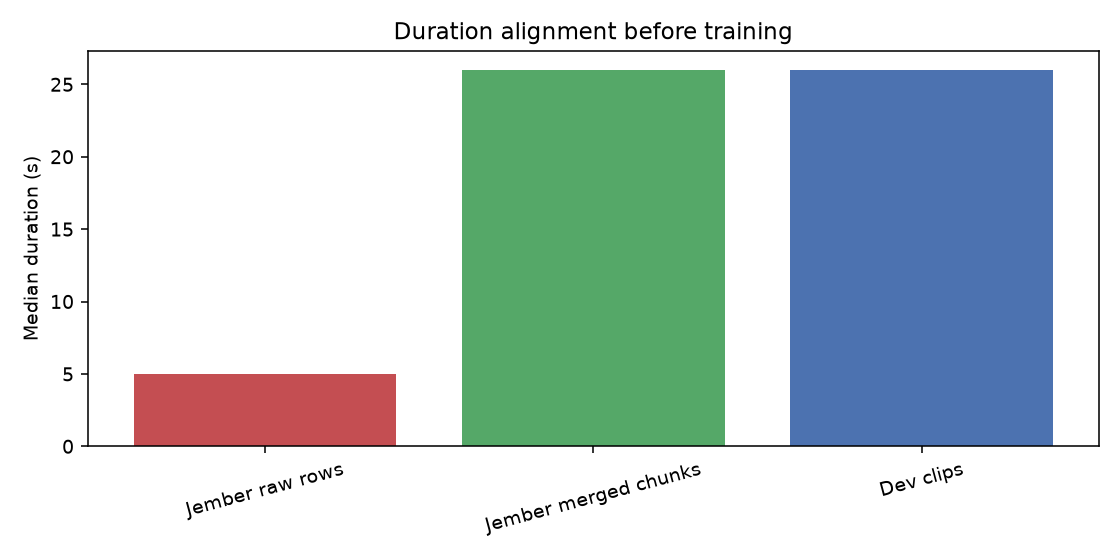

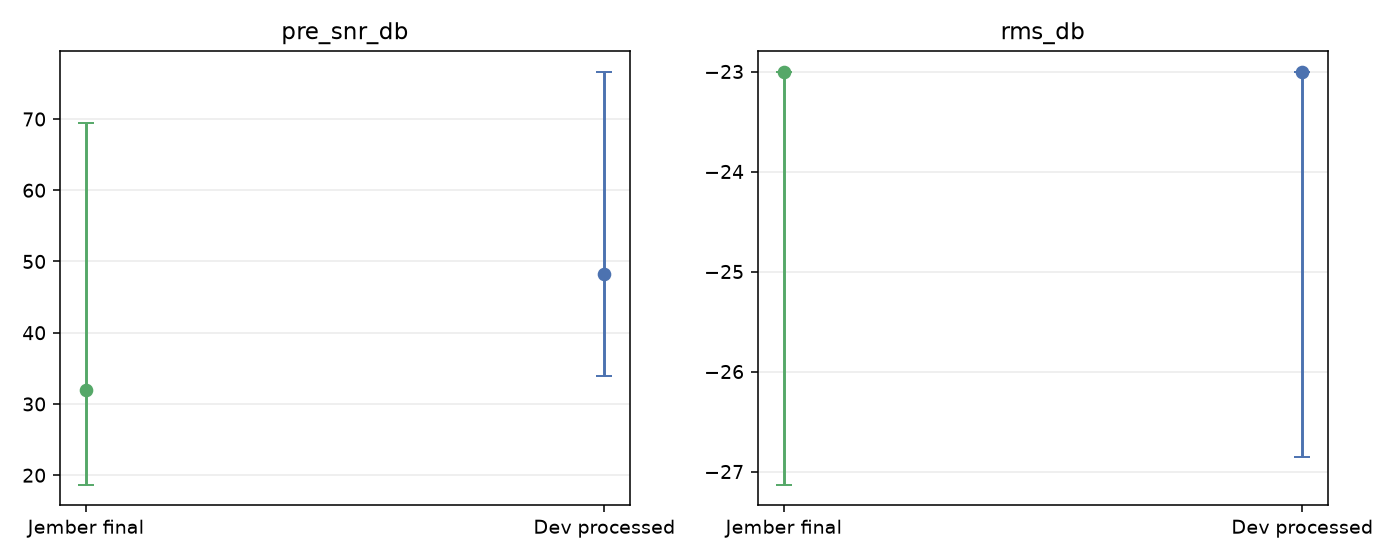

In [6]:
eda_dir = processed_dir / "eda"
eda_files = [
    "duration_summary.tsv", "merge_variants.tsv", "boundary_summary.tsv",
    "quality_summary.tsv", "vocabulary_summary.tsv", "dev_language_counts.tsv",
    "dev_audio_by_group.tsv", "jember_unicode_inventory.tsv",
    "dev_unicode_inventory.tsv", "dev_oov.tsv",
]
for filename in eda_files:
    path = eda_dir / filename
    if path.exists():
        display(Markdown("### " + filename))
        table = pd.read_csv(path, sep="\t")
        display(table.head(30))
for filename in ["duration_summary.png", "quality_summary.png"]:
    path = eda_dir / filename
    if path.exists():
        display(Image(filename=str(path)))

## Cell 12 — preprocessing summary and inference

### What the first 11 cells established

| Step | Evidence from the EDA | How it improved the dataset |
|---|---|---|
| Source audit | Jember has 208 sessions, 6,679 metadata rows, and mixed native rates (119 files at 48 kHz and 89 at 44.1 kHz). Dev has 372 clips from two conversations: 352 `javind`, 20 `ind`, and no `jav` clips. | The pipeline is built around the data that is actually present, not the brief's assumptions. The missing `jav` slice and tiny `ind` slice are recorded as evaluation limitations. |
| Audio-duration integrity | 41 structurally invalid Jember rows were removed; valid timestamps were clamped to decoded audio duration. The boundary EDA shows 0% gaps over 1 second, 99.97% exact adjacency, and only two overlapping boundaries. | Training never slices past real audio or learns from empty/negative intervals. MP3 header padding cannot leak into the targets. |
| Training-text normalization | Jember contains large scholarly-orthography counts (`ê`, `è`, `ě`, and `ḍ`), while dev uses almost none of those marks and instead has a small number of `é` characters. | Jember targets now match the target spelling convention much better without blanket lowercasing or destroying hyphens, apostrophes, casing, or attached ellipses. Dev references remain verbatim. |
| Scorer alignment | The official normalizer is kept separate and used for diagnostic word counts/OOV tables. The current artifact measures 17,485 dev scorer tokens and 3,227 dev OOV tokens after training-text normalization (18.46%). | We optimize against the real WER tokenization while avoiding a dangerous rewrite of labels that the scorer itself will normalize later. |
| Lossless merging | 6,638 usable rows become 1,472 plain chunks. Median duration moves from 5.0 s to 26.0 s; 92.53% of merged chunks fall in the 15–32 s band versus 92.47% of dev clips. | The training duration prior now matches the target distribution while preserving the original audio and transcript order. A 1,552-chunk turn-aware candidate is retained for later ablation. |
| Boundary treatment | Jember timestamps are whole-second quantized. Every plain chunk receives up to 150 ms of neighboring context, followed by capped, edge-only VAD. `pad_hot` is retained as an explicit risk flag rather than hidden. | Boundary words are less likely to be cut, while interior speech is never deleted. The flag makes the possible neighboring-speaker import measurable. |
| Loudness standardization | Final RMS is centered around −23 dBFS, with a −1 dBFS ceiling and zero clipping introduced. Jember's pre-normalization quality is materially more variable: median SNR 31.9 dB versus dev's 48.2 dB. | Encoder inputs are on a consistent scale without compression or limiting. The EDA also shows that Jember remains acoustically harder than dev, so normalization improves stability but does not pretend to remove real noise. |
| Quality gate and provenance | 1,472 materialized chunks become 1,471 usable chunks; only one 1.415 s chunk is excluded. Flags identify 98 off-mic, 151 low-SNR, 129 hot-peak, and 34 clipped-session examples. | Only degenerate data is removed. All decisions, source rows, metrics, flags, and bounded future sampling weights remain auditable. |
| Leakage-safe split | The final set has 1,309 train chunks and 162 heldout chunks across disjoint sessions (180 train sessions, 28 heldout sessions). | Local model choices can be tested without the same recording session appearing on both sides. `dev_df` stays validation-only. |

### Overall inference

The preprocessing work has fixed the high-confidence, data-side problems: inconsistent Jember
orthography, unreliable timestamp boundaries, the 5-second-versus-26-second duration mismatch,
mixed source audio formats, and uncontrolled level variation. The final artifact is therefore
cleaner, length-matched, scorer-aware, and reproducible without throwing away meaningful speech.

The EDA says the remaining difficulty is mostly a domain problem rather than a cleaning problem:
Jember is Javanese-matrix spontaneous speech with more noise, more boundary uncertainty, and
likely multi-speaker overlap, while dev is predominantly Indonesian-matrix speech from only two
conversations. Preprocessing cannot safely manufacture that missing target distribution. This is
why the notebook keeps the plain merge as the primary set, exposes turn-aware and quality fields
as ablations, and does not use dev transcripts for lexical mapping or training decisions.

For the next phase, fit only on `train_only_df`, tune preprocessing/model choices on `heldout_df`,
and use `dev_df` as the final validation report. The strongest first comparisons are plain versus
turn-aware boundaries, equal versus bounded quality sampling, and a conservative model adaptation
that preserves Indonesian competence while learning Jember acoustics.